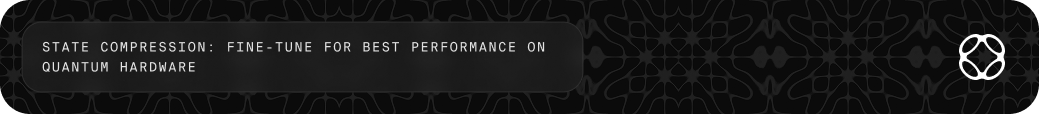

Use the `fine_tuning` parameter in `haiqu.state_compression()` to optimize circuit compression for best performance on quantum hardware.

- For a 10-step Heisenberg evolution circuit, fine-tuning increases compression quality from 73% to 82% **(12.3% improvement)**.

### Encountered an issue? Let us know

Found a bug or have a question? [Submit feedback](https://feedback.haiqu.ai/)

### `haiqu.state_compression(): fine_tuning`

- **What does it do?** This parameter optimizes the compressed circuit, improving performance on quantum hardware.
- **How do I use it?** Pass `fine_tuning` as a parameter to `haiqu.state_compression()` when creating a compression job, then retrieve results with `job.result()`.
- **What are the options?**
  - `disabled` – no fine-tuning performed.
  - `low` (default) – boosts performance on quantum hardware. Marginally increases computational demand of `state_compression`.
  - `heavy` – achieves the best performance on quantum hardware. Greatly increases computational demand of `state_compression`.
- **Which option do you recommend?** Start with the default `low` setting. Use `heavy` when you can afford to wait for `state_compression` to run in order to achieve maximum performance on quantum hardware.

## Initialize the benchmark

Import the necessary libraries, initialize the Haiqu SDK, and create an adder circuit to demonstrate state compression. The adder circuit adds two integers m and k.

In [1]:
import pandas as pd
import numpy as np
import qiskit

from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import SparsePauliOp

from haiqu.sdk import haiqu

haiqu.login()
haiqu.init("State Compression Tutorial")

def build_heisenberg_evolution_circuit(num_qubits, w, t, num_steps, seed=None):
    """
    Builds a quantum circuit of Trotterized Heisenberg evolution, started from the antiferromagnetic state.
    
    Parameters:
    - num_qubits (int): Number of qubits.
    - w (float): Intensity of the disorder
    - t (float): Time step
    - num_steps (int): Number of Trotter steps
    - seed (int|None): optional seed for setting the random field
    
    Returns:
    - QuantumCircuit implementing the Trotter evolution.
    """
    rng = np.random.default_rng(seed=seed)  # we specify the seed to be able to reproduce the circuits
    h_x = rng.uniform(-w, w, size=num_qubits)
    h_z = rng.uniform(-w, w, size=num_qubits)

    paulis = []  # pauli strings
    coeffs = []  # coefficients of the corresponding strings

    for i in range(num_qubits - 1):  # add ZZ, XX, YY components
        for op in ["Z", "X", "Y"]:
            pauli = ["I"] * num_qubits
            pauli[i] = op
            pauli[i + 1] = op
            
            paulis.append("".join(pauli))
            coeffs.append(1)

    # adding disorder components
    for i in range(num_qubits):
        pauli = ["I"] * num_qubits
        pauli[i] = "X"
        paulis.append("".join(pauli))
        coeffs.append(h_x[i])
    
        pauli = ["I"] * num_qubits
        pauli[i] = "Z"
        paulis.append("".join(pauli))
        coeffs.append(h_z[i])

    hamiltonian = SparsePauliOp(paulis, coeffs)  # creating the hamiltonian

    # creating an antiferromagnetic state
    qc_init = qiskit.QuantumCircuit(num_qubits)
    for i in range(0, num_qubits, 2):
        qc_init.x(i)

    # a circuit, implementing a single Trotter step
    trotter_step = PauliEvolutionGate(hamiltonian, time=t)

    # building the evolution circuit
    qc = qc_init.copy()
    for i in range(num_steps):
        qc = qc.compose(trotter_step)
    qc.name = "evolution"
    
    return qc

evolution_circuit = build_heisenberg_evolution_circuit(25, 1, 0.1, 10, seed=42)

evolution_circuit_meta = haiqu.transpile(evolution_circuit, device=haiqu.get_device("aer_simulator"))
evolution_circuit_meta.core_metrics()

CIRCUIT,evolution-on-aer_simulator
QUBITS,25
NUM PARAMETERS,0
DEPTH,137
2-Q GATES DEPTH,126
1-Q GATES,263
2-Q GATES,720
OTHER GATES,0
GATES TOTAL,983
OTHER OPERATIONS,0
INSTRUCTIONS TOTAL,983


## Run benchmark scenarios

Run experiments comparing original circuit, compressed circuit, and compressed circuit with mitigation on a noisy device:

In [2]:
# Initialize scenarios.
scenarios = [
    {"fine_tuning": "disabled", "description": "No fine-tuning"},
    {"fine_tuning": "low", "description": "Low fine-tuning"},
    {"fine_tuning": "heavy", "description": "Extensive fine-tuning"},
]
# Loop over scenarios and initialize results.
results = []
for scenario in scenarios:
    job_h = haiqu.state_compression(circuit=evolution_circuit, fine_tuning=scenario["fine_tuning"])
    circuit = job_h.result()

    compression_time = job_h.info["compression_time"]
    
    # Store results for summary table.
    results.append({"compression_time": compression_time, "quality": job_h.quality, "description": scenario["description"]})

Fine-tuning can greatly affect the state compression quality. Summary of results:

In [3]:
def build_summary(results):
    """Build summary table data from experiment results."""
    return {
        'Configuration': [r["description"] for r in results],
        'Compression time': [r["compression_time"] for r in results],
        'Compression quality': [r["quality"] for r in results],
        'Business Impact': [
            'Base compression quality and fast result',
            'Significan quality boost with low time cost',
            'Maximally improved quality with high time cost',
        ]
    }

pd.DataFrame(build_summary(results))

,Configuration,Compression time,Compression quality,Business Impact
0,No fine-tuning,18.881220,0.737452,Base compression quality and fast result
1,Low fine-tuning,32.827189,0.794300,Significan quality boost with low time cost
2,Extensive fine-tuning,72.072588,0.821093,Maximally improved quality with high time cost


> **🎲 Note:** Due to the stochastic nature of quantum sampling, these results will differ slightly between runs.

> **💡 Good to Know:** By default State Compression automatically sets the approximation level from noise profile data of a targeted hardware. An advanced user is free to set its own `approximation_level` to change the quality of the result even further.

## Get in Touch

- **Documentation:** [docs.haiqu.ai](https://docs.haiqu.ai/)
- **Support & feedback:** [feedback.haiqu.ai](https://feedback.haiqu.ai/)
- **LinkedIn:** [Haiqu on LinkedIn](https://www.linkedin.com/company/haiquai/posts/?feedView=all)
- **Website:** [haiqu.ai](https://haiqu.ai/)
- **Business inquiries:** [info@haiqu.ai](mailto:info@haiqu.ai)

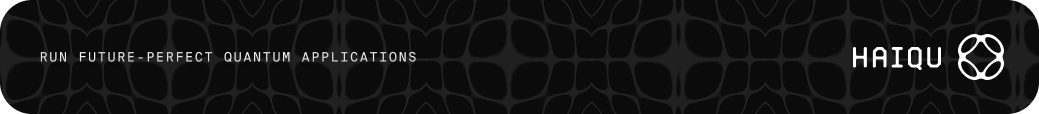